In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Vérifier si GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cpu


In [2]:
DATA_DIR     = r"C:\Users\menga\PycharmProjects\PythonProjecteffectif\data\eye_diseases"
FIGURES_DIR  = r"C:\Users\menga\PycharmProjects\PythonProjecteffectif\outputs\figures"
CHECKPOINT_DIR = r"C:\Users\menga\PycharmProjects\PythonProjecteffectif\outputs\checkpoints"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Paramètres
IMG_SIZE   = 224   # EfficientNet attend 224x224
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 1e-3
NUM_CLASSES = 4
CLASSES    = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]

print("Configuration prête ")

Configuration prête 


In [3]:
# Augmentation UNIQUEMENT pour le train
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),              # flip horizontal
    transforms.RandomRotation(10),                  # rotation ±10°
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),                                              # variation luminosité/contraste
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],                # valeurs ImageNet
        std=[0.229, 0.224, 0.225]
    )
])

# Pas d'augmentation pour val et test
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transformations définies ")

Transformations définies 


In [4]:
# Chargement complet sans transform d'abord
full_dataset = datasets.ImageFolder(root=DATA_DIR)
print("Classes détectées :", full_dataset.classes)
print("Total images :", len(full_dataset))

# Split : 70% train / 15% val / 15% test
total = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # reproductible
)

print(f"\nTrain : {len(train_dataset)} images")
print(f"Val   : {len(val_dataset)} images")
print(f"Test  : {len(test_dataset)} images")

Classes détectées : ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Total images : 4217

Train : 2951 images
Val   : 632 images
Test  : 634 images


In [5]:
# On applique les bonnes transforms à chaque split
train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform   = val_test_transforms
test_dataset.dataset.transform  = val_test_transforms

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders prêts ")
print(f"Batches train : {len(train_loader)}")
print(f"Batches val   : {len(val_loader)}")

DataLoaders prêts 
Batches train : 93
Batches val   : 20


In [6]:
# Récupérer les labels du train set
train_labels = [full_dataset.targets[i] for i in train_dataset.indices]

# Calculer les poids pour équilibrer les classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2, 3]),
    y=train_labels
)

class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print("Class weights :", class_weights)

Class weights : [1.02750696 0.94462228 1.05694842 0.97844828]


In [10]:
# Charger EfficientNetB0 pré-entraîné sur ImageNet
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=NUM_CLASSES)
model = model.to(device)

# Compter les paramètres
total_params = sum(p.numel() for p in model.parameters())
print(f"Paramètres totaux     : {total_params:,}")
print(f"Modèle chargé sur     : {device} ")

Paramètres totaux     : 4,012,672
Modèle chargé sur     : cpu 


In [14]:
# Loss avec class weights
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer Adam
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Scheduler : réduit le LR si val_loss stagne
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

print("Loss     : CrossEntropyLoss avec class weights ")
print("Optimizer: Adam (lr=1e-3) ")
print("Scheduler: ReduceLROnPlateau ")

Loss     : CrossEntropyLoss avec class weights ✅
Optimizer: Adam (lr=1e-3) ✅
Scheduler: ReduceLROnPlateau ✅


In [15]:
# Historique pour les courbes
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [],  'val_acc': []
}

# Early stopping
best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 5  # arrête si pas d'amélioration après 5 epochs

print("Début de l'entraînement...\n")

for epoch in range(EPOCHS):

    # ── TRAIN ──────────────────────────────────────────
    model.train()
    train_loss, train_correct = 0.0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc   = train_correct / len(train_dataset)

    # ── VALIDATION ─────────────────────────────────────
    model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            val_loss    += loss.item()
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc   = val_correct / len(val_dataset)

    # Scheduler step
    scheduler.step(val_loss)

    # Sauvegarder le meilleur modèle
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(),
                   os.path.join(CHECKPOINT_DIR, "best_model.pt"))
        saved = "✅ modèle sauvegardé"
    else:
        patience_counter += 1
        saved = f"(patience {patience_counter}/{PATIENCE})"

    # Historique
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | {saved}")

    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping déclenché à l'epoch {epoch+1}")
        break

print("\nEntraînement terminé ✅")

Début de l'entraînement...

Epoch 01/20 | Train Loss: 0.8963 Acc: 0.7963 | Val Loss: 0.2945 Acc: 0.8861 | ✅ modèle sauvegardé
Epoch 02/20 | Train Loss: 0.4201 Acc: 0.8675 | Val Loss: 0.3577 Acc: 0.8671 | (patience 1/5)
Epoch 03/20 | Train Loss: 0.4535 Acc: 0.8895 | Val Loss: 0.2527 Acc: 0.9082 | ✅ modèle sauvegardé
Epoch 04/20 | Train Loss: 0.2883 Acc: 0.9072 | Val Loss: 0.3323 Acc: 0.8924 | (patience 2/5)
Epoch 05/20 | Train Loss: 0.2101 Acc: 0.9261 | Val Loss: 0.2001 Acc: 0.9272 | ✅ modèle sauvegardé
Epoch 06/20 | Train Loss: 0.1380 Acc: 0.9475 | Val Loss: 0.2346 Acc: 0.9320 | (patience 3/5)
Epoch 07/20 | Train Loss: 0.0885 Acc: 0.9681 | Val Loss: 0.2728 Acc: 0.9320 | (patience 4/5)
Epoch 08/20 | Train Loss: 0.0666 Acc: 0.9793 | Val Loss: 0.2615 Acc: 0.9241 | (patience 5/5)

Early stopping déclenché à l'epoch 8

Entraînement terminé ✅


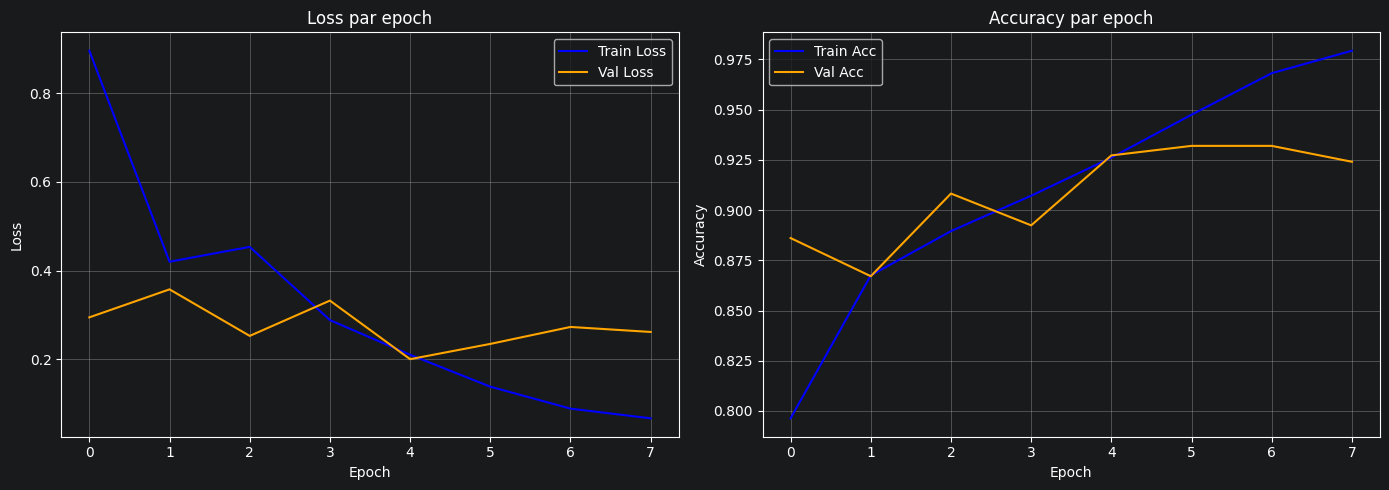

Courbes sauvegardées 


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe Loss
axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='orange')
axes[0].set_title('Loss par epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Courbe Accuracy
axes[1].plot(history['train_acc'], label='Train Acc', color='blue')
axes[1].plot(history['val_acc'],   label='Val Acc',   color='orange')
axes[1].set_title('Accuracy par epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "courbes_entrainement.png"))
plt.show()
print("Courbes sauvegardées ")

In [17]:
# Recharger le meilleur modèle sauvegardé
model.load_state_dict(torch.load(
    os.path.join(CHECKPOINT_DIR, "best_model.pt"),
    map_location=device
))

# Dégeler seulement les 30 dernières couches
layers = list(model.parameters())
for param in layers[:-30]:
    param.requires_grad = False  # geler
for param in layers[-30:]:
    param.requires_grad = True   # dégeler

# Optimizer avec LR très faible pour le fine-tuning
optimizer_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4  # 10x plus petit que avant
)

scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft, mode='min', factor=0.5, patience=2
)

print("Fine-tuning configuré ")
print(f"LR réduit à 1e-4")

Fine-tuning configuré ✅
LR réduit à 1e-4


In [19]:
EPOCHS_FT = 10
history_ft = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [],  'val_acc': []
}

best_val_loss_ft = float('inf')
patience_counter_ft = 0
PATIENCE_FT = 4

print("Début du fine-tuning...\n")

for epoch in range(EPOCHS_FT):

    # ── TRAIN ──────────────────────────────────────
    model.train()
    train_loss, train_correct = 0.0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_ft.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_ft.step()

        train_loss    += loss.item()
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc   = train_correct / len(train_dataset)

    # ── VALIDATION ─────────────────────────────────
    model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            val_loss    += loss.item()
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc   = val_correct / len(val_dataset)

    scheduler_ft.step(val_loss)

    # Sauvegarder le meilleur modèle
    if val_loss < best_val_loss_ft:
        best_val_loss_ft = val_loss
        torch.save(model.state_dict(),
                   os.path.join(CHECKPOINT_DIR, "best_model_finetuned.pt"))
        saved = " modèle sauvegardé"
        patience_counter_ft = 0
    else:
        patience_counter_ft += 1
        saved = f"(patience {patience_counter_ft}/{PATIENCE_FT})"

    history_ft['train_loss'].append(train_loss)
    history_ft['val_loss'].append(val_loss)
    history_ft['train_acc'].append(train_acc)
    history_ft['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS_FT} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | {saved}")

    if patience_counter_ft >= PATIENCE_FT:
        print(f"\nEarly stopping déclenché à l'epoch {epoch+1}")
        break

print("\nFine-tuning terminé ")

Début du fine-tuning...

Epoch 01/10 | Train Loss: 0.0736 Acc: 0.9729 | Val Loss: 0.2111 Acc: 0.9335 |  modèle sauvegardé
Epoch 02/10 | Train Loss: 0.0674 Acc: 0.9776 | Val Loss: 0.2340 Acc: 0.9351 | (patience 1/4)
Epoch 03/10 | Train Loss: 0.0564 Acc: 0.9776 | Val Loss: 0.2747 Acc: 0.9304 | (patience 2/4)
Epoch 04/10 | Train Loss: 0.0549 Acc: 0.9814 | Val Loss: 0.2534 Acc: 0.9383 | (patience 3/4)
Epoch 05/10 | Train Loss: 0.1081 Acc: 0.9848 | Val Loss: 0.2676 Acc: 0.9320 | (patience 4/4)

Early stopping déclenché à l'epoch 5

Fine-tuning terminé 
